# taiwanese students what they major in and USA visa
## data that i used

- IIE Open Doors: Taiwanese students in the U.S. by academic year
- ICE SEVIS by the Numbers: F-1 students by major
- USCIS of H-1B Workers
- Taiwan Ministry of Education
- Central Bank of Taiwan
- Taiwan National Statistics in majors within Taiwan


In [15]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import numpy as np
import glob, os
from matplotlib.patches import Patch

# Optional styling - graceful fallback if seaborn/scipy not installed
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="muted")
except ImportError:
    plt.style.use("default")
    print("(seaborn not installed, using default matplotlib style)")

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA = "."

# Load every CSV as its own SQL table in one loop
conn = sqlite3.connect(":memory:")
for path in sorted(glob.glob(f"{DATA}/*.csv")):
    name = os.path.splitext(os.path.basename(path))[0].split("_", 1)[1]
    df = pd.read_csv(path)
    df.to_sql(name, conn, index=False, if_exists="replace")
    print(f"  loaded '{name}': {df.shape[0]} rows")

print(f"\nSQLite ready: {sqlite3.sqlite_version}")
print(f"Pandas: {pd.__version__}")

  loaded 'taiwan_students_in_us': 11 rows
  loaded 'taiwan_level_composition': 16 rows
  loaded 'sevis_top_majors_2024': 20 rows
  loaded 'h1b_approvals_by_country_fy2023': 12 rows
  loaded 'h1b_petitions_by_major_fy2023': 20 rows
  loaded 'h1b_top_metros_fy2023': 15 rows
  loaded 'ntd_usd_fx': 11 rows
  loaded 'taiwan_fields_of_study': 10 rows
  loaded 'taiwan_study_destinations': 14 rows
  loaded 'top_us_universities_intl': 15 rows
  loaded 'taiwan_domestic_majors': 11 rows

SQLite ready: 3.50.4
Pandas: 3.0.1


In [16]:
import os
print(os.listdir("."))

['07_ntd_usd_fx.csv', '08_taiwan_fields_of_study.csv', '03_sevis_top_majors_2024.csv', '02_taiwan_level_composition.csv', '01_taiwan_students_in_us.csv', '06_h1b_top_metros_fy2023.csv', '04_h1b_approvals_by_country_fy2023.csv', '09_taiwan_study_destinations.csv', 'taiwan_full_walkthrough.ipynb', '11_taiwan_domestic_majors.csv', '.ipynb_checkpoints', '05_h1b_petitions_by_major_fy2023.csv', 'taiwan_visa_data_walkthrough.ipynb', '10_top_us_universities_intl.csv']


## 1. taiwanese students in the USA
IIE Open Doors annual reports between 2014-2024

In [3]:
taiwan_us = pd.read_csv("01_taiwan_students_in_us.csv")
taiwan_us

,academic_year,taiwan_students_in_us,rank_among_origin_countries
0,2014,21266,6
1,2015,20993,6
2,2016,21516,7
3,2017,21516,7
4,2018,22454,7
5,2019,23369,7
6,2020,23724,7
7,2021,19673,7
8,2022,20487,6
9,2023,21834,6


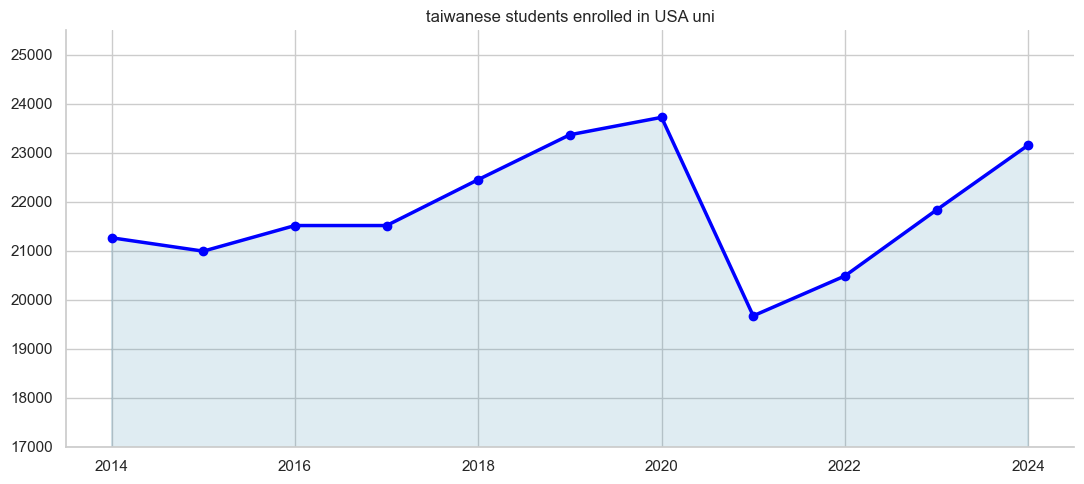

In [97]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(taiwan_us["academic_year"], taiwan_us["taiwan_students_in_us"],
        marker="o", linewidth=2.5, color="blue")
ax.fill_between(taiwan_us["academic_year"], taiwan_us["taiwan_students_in_us"],
                alpha=0.15, color="#2E86AB")

ax.set_title("taiwanese students enrolled in USA uni",)
ax.set_ylim(17000, 25500)
plt.tight_layout()
plt.show()

## 2. what do taiwanese students who go to the USA actually doing? (Looking at OPT)

In [100]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print("Tables in database:")
print(tables)

import os, glob
print("\nFiles in data/ folder:")
print(glob.glob("data/*.csv"))

Tables in database:
                               name
0             taiwan_students_in_us
1          taiwan_level_composition
2             sevis_top_majors_2024
3   h1b_approvals_by_country_fy2023
4     h1b_petitions_by_major_fy2023
5             h1b_top_metros_fy2023
6                        ntd_usd_fx
7            taiwan_fields_of_study
8         taiwan_study_destinations
9          top_us_universities_intl
10           taiwan_domestic_majors

Files in data/ folder:
[]


In [19]:
q = '''
SELECT level,
       MAX(CASE WHEN academic_year=2020 THEN percent END) AS "2020",
       MAX(CASE WHEN academic_year=2022 THEN percent END) AS "2022",
       MAX(CASE WHEN academic_year=2023 THEN percent END) AS "2023",
       MAX(CASE WHEN academic_year=2024 THEN percent END) AS "2024"
FROM taiwan_level_composition
GROUP BY level
ORDER BY "2024" DESC;
'''
pd.read_sql(q, conn)

,level,2020,2022,2023,2024
0,Graduate,39.3,43.9,45.7,43.1
1,OPT,23.2,23.0,23.7,28.3
2,Undergraduate,31.1,29.0,26.6,24.1
3,Non-degree,6.4,3.0,4.0,4.5


## 3. what do international students study in general?

ICE SEVIS by the Numbers, 2024

In [21]:
q = '''
SELECT CASE WHEN is_stem=1 THEN 'STEM' ELSE 'Non-STEM' END AS category,
       COUNT(*) AS n_majors,
       SUM(student_count) AS total_students,
       ROUND(100.0 * SUM(student_count) / (SELECT SUM(student_count) FROM sevis_top_majors_2024), 1) AS pct
FROM sevis_top_majors_2024
GROUP BY is_stem
ORDER BY total_students DESC;
'''
pd.read_sql(q, conn)

,category,n_majors,total_students,pct
0,STEM,11,609500,63.4
1,Non-STEM,9,352000,36.6


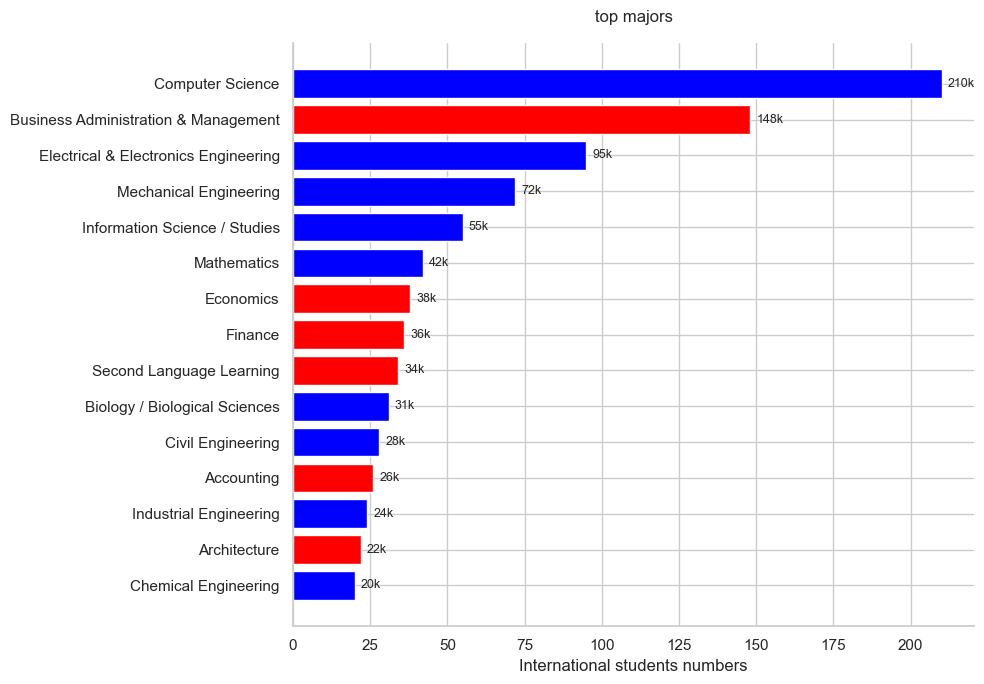

In [83]:
sevis = pd.read_csv(f"{DATA}/03_sevis_top_majors_2024.csv")
top = sevis.sort_values("student_count", ascending=True).tail(15)
colors = ["blue" if s else "red" for s in top["is_stem"]]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top["major"], top["student_count"]/1000, color=colors)
ax.set_xlabel("International students numbers")
ax.set_title("top majors",
             fontsize=12, pad=15)
for i, (maj, val) in enumerate(zip(top["major"], top["student_count"]/1000)):
    ax.text(val + 2, i, f"{val:.0f}k", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 4. H-1B approvals by country of birth

USCIS via Pew Research FOIA analysis in the year of 2023

In [23]:
q = '''
WITH ranked AS (
    SELECT country, approvals_fy2023, pct_of_total,
           RANK() OVER (ORDER BY approvals_fy2023 DESC) AS rnk
    FROM h1b_approvals_by_country_fy2023
)
SELECT rnk AS "Rank", country AS "Country",
       printf('%,d', approvals_fy2023) AS "Approvals",
       pct_of_total AS "% of total"
FROM ranked
ORDER BY rnk;
'''
pd.read_sql(q, conn)

,Rank,Country,Approvals,% of total
0,1,India,"280,000",73.0
1,2,China,"46,000",12.0
2,3,Philippines,"5,500",1.4
3,4,South Korea,"5,200",1.4
4,5,Canada,"4,800",1.3
5,6,Taiwan,"4,100",1.1
6,7,Mexico,"3,200",0.8
7,8,Pakistan,"2,900",0.8
8,9,Nepal,"2,700",0.7
9,10,United Kingdom,"2,500",0.7


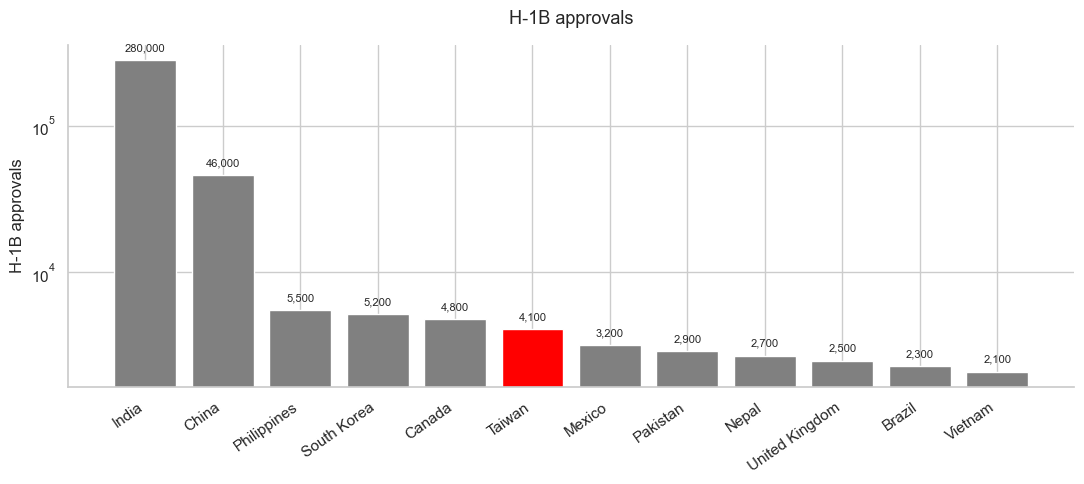

In [80]:
h1b_country = pd.read_csv(f"{DATA}/04_h1b_approvals_by_country_fy2023.csv")
fig, ax = plt.subplots(figsize=(11, 5))
colors = ["red" if c == "Taiwan" else "gray" for c in h1b_country["country"]]
bars = ax.bar(h1b_country["country"], h1b_country["approvals_fy2023"], color=colors)
ax.set_yscale("log")
ax.set_ylabel("H-1B approvals")
ax.set_title("H-1B approvals",
             fontsize=13, pad=15)
plt.xticks(rotation=35, ha="right")
for bar, val in zip(bars, h1b_country["approvals_fy2023"]):
    ax.text(bar.get_x() + bar.get_width()/2, val*1.15,
            f"{val:,}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

taiwan is 6th at 1.1%. Most H-1B volume flows through large IT services firms with dense Indian pipelines the lottery itself doesn't discriminate by country, but sponsorship does.

## 5. Does your major predict your H-1B chances?

SQL JOIN between SEVIS majors and H-1B petitions filed in matching occupation buckets.

In [25]:
q = '''
SELECT m.major,
       m.student_count          AS students_sevis,
       o.h1b_petitions_fy2023   AS h1b_petitions,
       ROUND(1.0 * o.h1b_petitions_fy2023 / m.student_count, 2) AS h1b_per_student,
       CASE WHEN m.is_stem=1 THEN 'STEM' ELSE 'Non-STEM' END AS category
FROM sevis_top_majors_2024 m
JOIN h1b_petitions_by_major_fy2023 o USING(major)
ORDER BY h1b_per_student DESC;
'''
conversion = pd.read_sql(q, conn)
conversion

,major,students_sevis,h1b_petitions,h1b_per_student,category
0,Computer Science,210000,265000,1.26,STEM
1,Data Science & Analytics,14500,11000,0.76,STEM
2,Finance,36000,14000,0.39,Non-STEM
3,Mathematics,42000,16000,0.38,STEM
4,Electrical & Electronics Engineering,95000,34000,0.36,STEM
5,Civil Engineering,28000,8500,0.30,STEM
6,Accounting,26000,7200,0.28,Non-STEM
7,Industrial Engineering,24000,6500,0.27,STEM
8,Mechanical Engineering,72000,18000,0.25,STEM
9,Biology / Biological Sciences,31000,7800,0.25,STEM


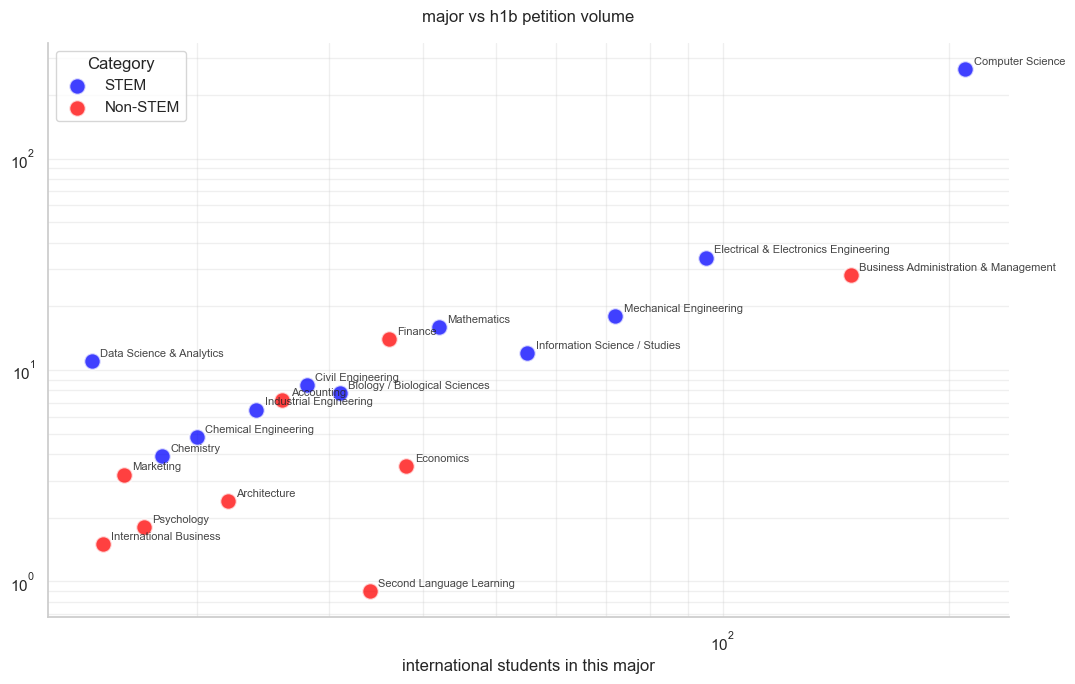

Pearson correlation (on log values): 0.799


In [77]:
fig, ax = plt.subplots(figsize=(11, 7))
for cat, color in [("STEM", "blue"), ("Non-STEM", "red")]:
    subset = conversion[conversion["category"] == cat]
    ax.scatter(subset["students_sevis"]/1000, subset["h1b_petitions"]/1000,
               s=140, color=color, alpha=0.75, edgecolor="white",
               linewidth=1.5, label=cat)

for _, row in conversion.iterrows():
    ax.annotate(row["major"],
                (row["students_sevis"]/1000, row["h1b_petitions"]/1000),
                fontsize=8, alpha=0.85,
                xytext=(6, 3), textcoords="offset points")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("international students in this major")
ax.set_title("major vs h1b petition volume",
             fontsize=12, pad=15)
ax.legend(title="Category")
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# Pearson on log values — no scipy needed (unlike Spearman)
corr = np.log(conversion["students_sevis"]).corr(np.log(conversion["h1b_petitions"]))
print(f"Pearson correlation (on log values): {corr:.3f}")

**Finding:** Strong positive correlation, but nonlinear.

- CS is off-scale on both axes but H-1B petitions actually exceeds student count (existing workers in the pipeline).
- data science has the highest conversion ratio
- second language majors, pscyhology and architecture have high enrollment but weak h1b conversion

## 6. Where do H-1B jobs live? (interactive US map)

In [27]:
q = '''
SELECT metro, h1b_approvals,
       ROUND(100.0 * h1b_approvals / SUM(h1b_approvals) OVER (), 1) AS pct,
       ROUND(100.0 * SUM(h1b_approvals) OVER (ORDER BY h1b_approvals DESC)
             / SUM(h1b_approvals) OVER (), 1) AS cumulative_pct
FROM h1b_top_metros_fy2023
ORDER BY h1b_approvals DESC;
'''
pd.read_sql(q, conn)

,metro,h1b_approvals,pct,cumulative_pct
0,"New York-Newark-Jersey City, NY-NJ-PA",45000,14.7,14.7
1,"San Francisco-Oakland-Berkeley, CA",38000,12.4,27.1
2,"San Jose-Sunnyvale-Santa Clara, CA",36000,11.8,38.9
3,"Seattle-Tacoma-Bellevue, WA",28000,9.2,48.0
4,"Dallas-Fort Worth-Arlington, TX",24000,7.8,55.9
5,"Boston-Cambridge-Newton, MA-NH",20000,6.5,62.4
6,"Washington-Arlington-Alexandria, DC",19000,6.2,68.6
7,"Chicago-Naperville-Elgin, IL-IN-WI",18000,5.9,74.5
8,"Los Angeles-Long Beach-Anaheim, CA",16000,5.2,79.7
9,"Austin-Round Rock-Georgetown, TX",14000,4.6,84.3


In [86]:
import folium

metros = pd.read_csv(f"{DATA}/06_h1b_top_metros_fy2023.csv")
m = folium.Map(location=[39.5, -98.5], zoom_start=4, tiles="CartoDB positron")

max_val = metros["h1b_approvals"].max()
for _, row in metros.iterrows():
    radius = 10 + 40 * (row["h1b_approvals"] / max_val)
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        popup=folium.Popup(
            f"<b>{row['metro']}</b><br>H-1B approvals: {row['h1b_approvals']:,}",
            max_width=280),
        tooltip=f"{row['metro'].split(',')[0]}: {row['h1b_approvals']:,}",
        color="pink", fill=True, fill_color="pink",
        fill_opacity=0.55, weight=1.5,
    ).add_to(m)

title_html = '''
<div style="position: fixed; top: 10px; left: 50px; z-index: 9999;
     background: white; padding: 10px 14px; border-radius: 6px;
     box-shadow: 0 2px 6px rgba(0,0,0,0.15); font-family: sans-serif;">
  <b>Top 15 U.S. metros by H-1B approvals</b><br>
  <span style="font-size:12px; color:#555;">FY 2023 — bubble size proportional to approvals</span>
</div>
'''
m.get_root().html.add_child(folium.Element(title_html))
m

the bar area, NYC, and seattle absorb >40% of all approvals for h1b but austin and raleigh (north carolina) are sleeper hits for h1b

## 7. does the NTD and USD exchange rate predict taiwanese student flows?

In [29]:
q = '''
SELECT t.academic_year, t.taiwan_students_in_us, f.ntd_per_usd
FROM taiwan_students_in_us t
JOIN ntd_usd_fx f USING(academic_year)
ORDER BY academic_year;
'''
joined = pd.read_sql(q, conn)

pearson = joined["taiwan_students_in_us"].corr(joined["ntd_per_usd"])
print(f"Pearson correlation: {pearson:.3f}")
joined

Pearson correlation: 0.345


,academic_year,taiwan_students_in_us,ntd_per_usd
0,2014,21266,30.37
1,2015,20993,31.91
2,2016,21516,32.33
3,2017,21516,30.44
4,2018,22454,30.16
5,2019,23369,30.93
6,2020,23724,29.58
7,2021,19673,28.02
8,2022,20487,29.81
9,2023,21834,31.16


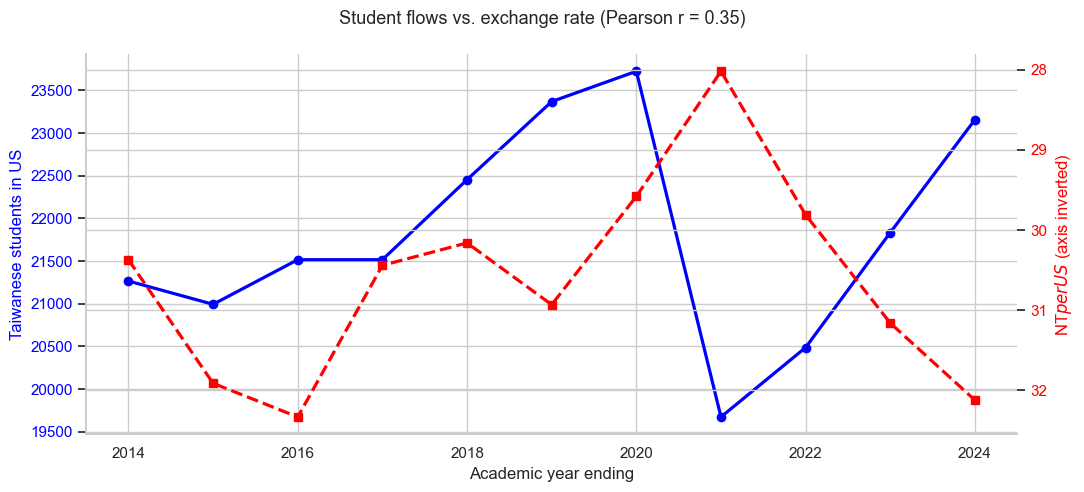

In [76]:
fig, ax1 = plt.subplots(figsize=(11, 5))
color1 = "blue"
ax1.plot(joined["academic_year"], joined["taiwan_students_in_us"],
         marker="o", color=color1, linewidth=2.3, label="Taiwanese students in US")
ax1.set_xlabel("Academic year ending")
ax1.set_ylabel("Taiwanese students in US", color=color1)
ax1.tick_params(axis="y", labelcolor=color1)

ax2 = ax1.twinx()
color2 = "red"
ax2.plot(joined["academic_year"], joined["ntd_per_usd"],
         marker="s", color=color2, linewidth=2.3, linestyle="--")
ax2.invert_yaxis()
ax2.set_ylabel("NT$ per US$ (axis inverted)", color=color2)
ax2.tick_params(axis="y", labelcolor=color2)
ax2.spines["top"].set_visible(False)
ax1.spines["top"].set_visible(False)

fig.suptitle(f"Student flows vs. exchange rate (Pearson r = {pearson:.2f})", fontsize=13)
plt.tight_layout()
plt.show()

# taiwanese students

## 8. what do taiwanese students in the USA actually major in?

IIE Open Doors 2022 Report (2021-22)

In [31]:
fields = pd.read_csv(f"{DATA}/08_taiwan_fields_of_study.csv")
fields = fields.sort_values("percent_of_taiwan_students", ascending=False)
fields

,field,percent_of_taiwan_students,category
0,STEM (combined),52.7,STEM
1,Business & Management,17.1,Non-STEM
2,Fine or Applied Arts,7.7,Non-STEM
3,Social Sciences,6.0,Non-STEM
4,Intensive English,3.9,Non-STEM
5,Humanities,3.2,Non-STEM
6,Health Professions,2.8,Non-STEM
9,Other / Undeclared,2.6,Non-STEM
7,Education,2.1,Non-STEM
8,Communications/Journalism,1.9,Non-STEM


<bound method _AxesBase.set_xlim of <Axes: title={'center': 'Taiwanese students in US 2021-22'}, xlabel='% of Taiwanese students'>>

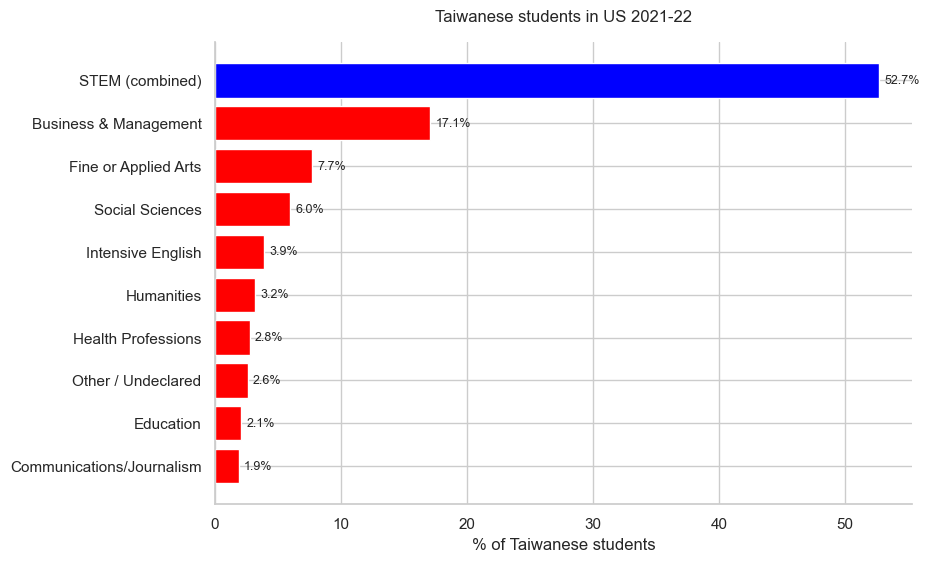

In [72]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(9, 6))

fields_sorted = fields.sort_values("percent_of_taiwan_students")
bar_colors = ["blue" if c == "STEM" else "red"
              for c in fields_sorted["category"]]

ax.barh(fields_sorted["field"], fields_sorted["percent_of_taiwan_students"],
        color=bar_colors)

# Value labels at the end of each bar
for i, (field, pct) in enumerate(zip(fields_sorted["field"],
                                      fields_sorted["percent_of_taiwan_students"])):
    ax.text(pct + 0.4, i, f"{pct}%", va="center", fontsize=9)

ax.set_xlabel("% of Taiwanese students")
ax.set_title("Taiwanese students in US 2021-22", fontsize=12, pad=15)
ax.set_xlim

52.7% of Taiwanese students in the US are in STEM.

## 9. where in the world do Taiwanese students go?

taiwan Ministry of Education, 2023 statistics

In [33]:
q = '''
SELECT destination_country, taiwan_students,
       ROUND(100.0 * taiwan_students /
             (SELECT SUM(taiwan_students) FROM taiwan_study_destinations WHERE year=2023), 1) AS pct
FROM taiwan_study_destinations
WHERE year = 2023
ORDER BY taiwan_students DESC;
'''
pd.read_sql(q, conn)

,destination_country,taiwan_students,pct
0,United States,21834,41.1
1,Australia,10673,20.1
2,Japan,5015,9.4
3,Canada,4240,8.0
4,United Kingdom,3685,6.9
5,Germany,2868,5.4
6,South Korea,2172,4.1
7,Poland,744,1.4
8,Spain,690,1.3
9,Netherlands,664,1.3


In [87]:
dest = pd.read_csv(f"{DATA}/09_taiwan_study_destinations.csv")
dest_2023 = dest[dest["year"] == 2023].copy()

m_world = folium.Map(location=[30, 30], zoom_start=2, tiles="CartoDB positron")

max_val = dest_2023["taiwan_students"].max()
for _, row in dest_2023.iterrows():
    radius = 8 + 35 * (row["taiwan_students"] / max_val)
    color = "pink" if row["destination_country"] == "United States" else "green"
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=radius,
        popup=folium.Popup(
            f"<b>{row['destination_country']}</b><br>"
            f"{row['taiwan_students']:,} Taiwanese students (2023)",
            max_width=280),
        tooltip=f"{row['destination_country']}: {row['taiwan_students']:,}",
        color=color, fill=True, fill_color=color,
        fill_opacity=0.65, weight=1.5,
    ).add_to(m_world)

folium.Marker(
    location=[23.7, 121.0],
    popup="<b>Taiwan</b><br>(origin)",
    tooltip="Taiwan — origin",
    icon=folium.Icon(color="orange", icon="star"),
).add_to(m_world)

title_html = '''
<div style="position: fixed; top: 10px; left: 50px; z-index: 9999;
     background: white; padding: 10px 14px; border-radius: 6px;
     box-shadow: 0 2px 6px rgba(0,0,0,0.15); font-family: sans-serif;">
  <b>Where Taiwanese students go abroad — 2023</b><br>
  <span style="font-size:12px; color:#555;">
    Red = US (dominant). Orange star = Taiwan (origin).
  </span>
</div>
'''
m_world.get_root().html.add_child(folium.Element(title_html))
m_world

In [92]:
q = '''
SELECT destination_country,
       MAX(CASE WHEN year=2021 THEN taiwan_students END) AS "2021",
       MAX(CASE WHEN year=2023 THEN taiwan_students END) AS "2023",
       ROUND(100.0 * (MAX(CASE WHEN year=2023 THEN taiwan_students END) -
                      MAX(CASE WHEN year=2021 THEN taiwan_students END)) /
                     MAX(CASE WHEN year=2021 THEN taiwan_students END), 1) AS pct_change
FROM taiwan_study_destinations
WHERE destination_country IN ('United States', 'Australia', 'Japan')
GROUP BY destination_country
ORDER BY "2023" DESC;
'''
pd.read_sql(q, conn)

,destination_country,2021,2023,pct_change
0,United States,19673,21834,11.0
1,Australia,15582,10673,-31.5
2,Japan,7174,5015,-30.1


## 10. which USA uni host the most international students?

In [36]:
q = '''
SELECT university, city, state, intl_students_2023_24
FROM top_us_universities_intl
ORDER BY intl_students_2023_24 DESC;
'''
pd.read_sql(q, conn)

,university,city,state,intl_students_2023_24
0,New York University,New York,NY,27247
1,Northeastern University,Boston,MA,21000
2,Columbia University,New York,NY,20321
3,University of Southern California,Los Angeles,CA,17469
4,Arizona State University,Tempe,AZ,17000
5,Univ. of Illinois Urbana-Champaign,Urbana,IL,13373
6,"University of California, Berkeley",Berkeley,CA,12020
7,Purdue University,West Lafayette,IN,10807
8,Carnegie Mellon University,Pittsburgh,PA,10800
9,"University of California, Los Angeles",Los Angeles,CA,10769


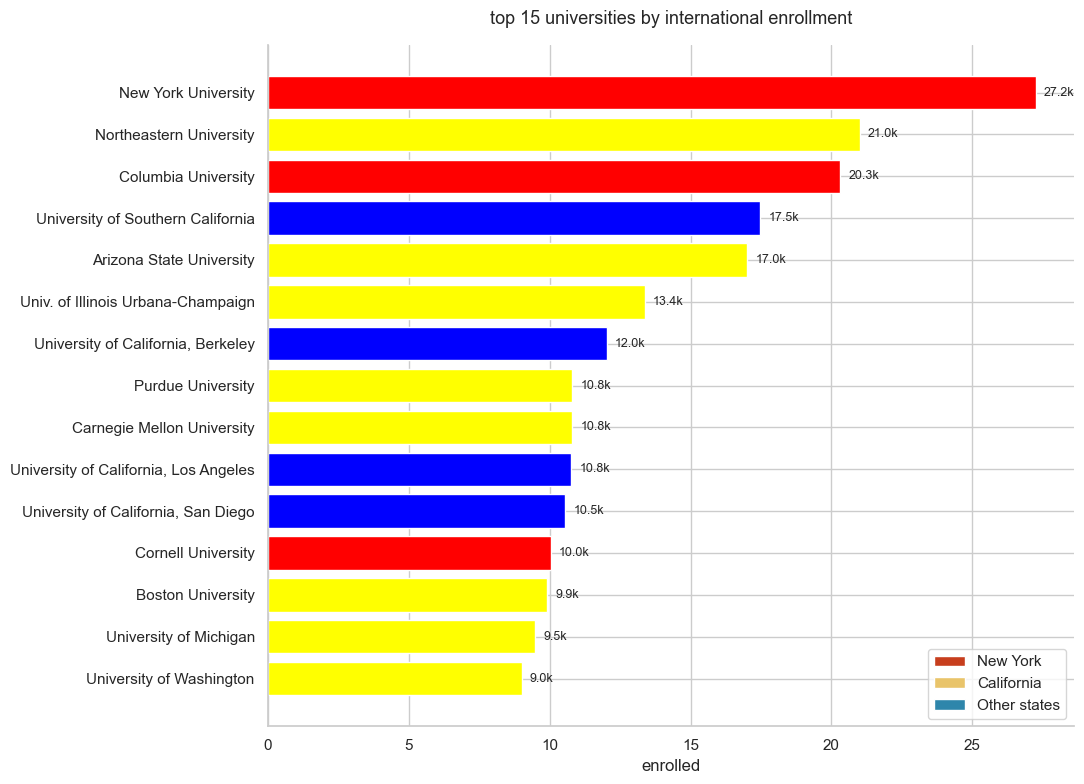

In [88]:
unis = pd.read_csv(f"{DATA}/10_top_us_universities_intl.csv")

fig, ax = plt.subplots(figsize=(11, 8))
unis_sorted = unis.sort_values("intl_students_2023_24")

colors = []
for _, row in unis_sorted.iterrows():
    if row["state"] == "NY":
        colors.append("red")
    elif row["state"] == "CA":
        colors.append("blue")
    else:
        colors.append("yellow")

ax.barh(unis_sorted["university"], unis_sorted["intl_students_2023_24"]/1000,
        color=colors)
for i, (uni, val) in enumerate(zip(unis_sorted["university"],
                                    unis_sorted["intl_students_2023_24"]/1000)):
    ax.text(val + 0.3, i, f"{val:.1f}k", va="center", fontsize=9)

ax.set_xlabel("enrolled")
ax.set_title("top 15 universities by international enrollment",
             fontsize=13, pad=15)

legend_elements = [
    Patch(facecolor="#C73E1D", label="New York"),
    Patch(facecolor="#E9C46A", label="California"),
    Patch(facecolor="#2E86AB", label="Other states"),
]
ax.legend(handles=legend_elements, loc="lower right")
plt.tight_layout()
plt.show()

## 11. What does taiwanese students study in taiwan vs abroad?

In [40]:
comparison = pd.DataFrame([
    ("Engineering/Tech",   31.0, 52.7),
    ("Business",           23.2, 17.1),
    ("Arts/Humanities",    14.7,  7.7),
    ("Social Sciences",    13.2,  6.0),
    ("Sciences/Health",    20.2,  2.8),
    ("Other",               4.7, 13.7),
], columns=["field_bucket", "domestic_pct", "abroad_pct"])
comparison["gap"] = comparison["abroad_pct"] - comparison["domestic_pct"]
comparison

,field_bucket,domestic_pct,abroad_pct,gap
0,Engineering/Tech,31.0,52.7,21.7
1,Business,23.2,17.1,-6.1
2,Arts/Humanities,14.7,7.7,-7.0
3,Social Sciences,13.2,6.0,-7.2
4,Sciences/Health,20.2,2.8,-17.4
5,Other,4.7,13.7,9.0


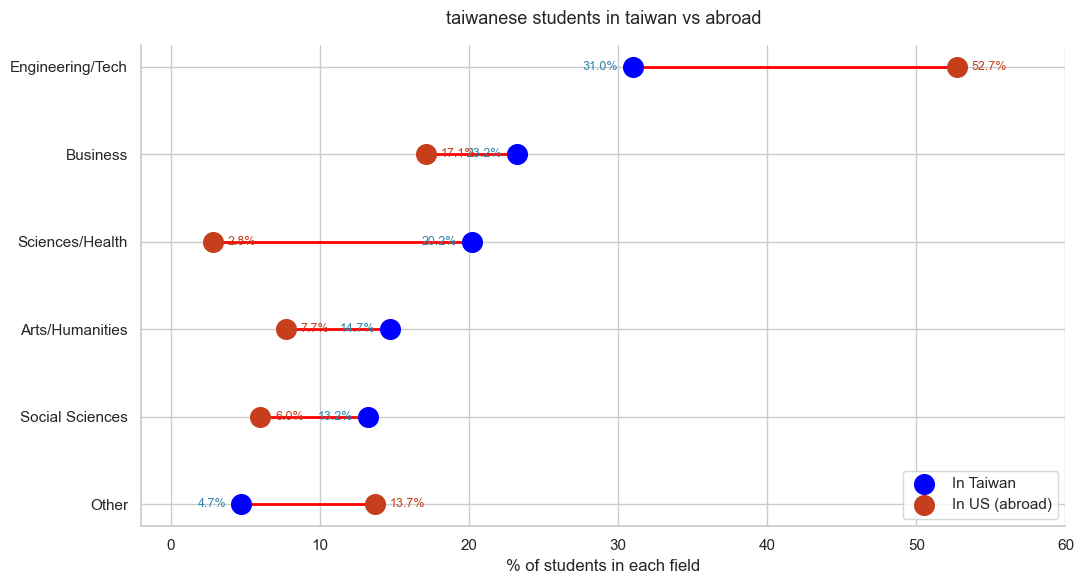

In [89]:
fig, ax = plt.subplots(figsize=(11, 6))

comparison_sorted = comparison.sort_values("domestic_pct")
y = np.arange(len(comparison_sorted))

for i, (_, row) in enumerate(comparison_sorted.iterrows()):
    ax.plot([row["domestic_pct"], row["abroad_pct"]], [i, i],
            color="red", linewidth=2, zorder=1)
    ax.scatter(row["domestic_pct"], i, s=200, color="blue",
               zorder=2, label="In Taiwan" if i == 0 else "")
    ax.scatter(row["abroad_pct"], i, s=200, color="#C73E1D",
               zorder=2, label="In US (abroad)" if i == 0 else "")
    ax.text(row["domestic_pct"] - 1, i, f"{row['domestic_pct']}%",
            ha="right", va="center", fontsize=9, color="#2E86AB")
    ax.text(row["abroad_pct"] + 1, i, f"{row['abroad_pct']}%",
            ha="left", va="center", fontsize=9, color="#C73E1D")

ax.set_yticks(y)
ax.set_yticklabels(comparison_sorted["field_bucket"])
ax.set_xlabel("% of students in each field")
ax.set_title("taiwanese students in taiwan vs abroad",
             fontsize=13, pad=15)
ax.legend(loc="lower right")
ax.set_xlim(-2, 60)
plt.tight_layout()
plt.show()

- there is a tech study abroad in crease from in taiwan of 31% → to abroad of 53%, Taiwanese students disproportionately leave specifically to study tech.
- business and arts are LESS popular abroad than at home, suggesting students pursuing these are more likely to stay in Taiwan.
- sciences/health crashes abroad 20% to 3% 